In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [15]:
df = pd.read_excel(
    r"E:\Regional Sales Dataset.xlsx",
    sheet_name="Sales Orders"
)

In [16]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [17]:
df.tail()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
64099,SO - 0007573,2018-02-28,74,Wholesale,USD,AXW291,825,26,12,1815.7,21788.4,980.478
64100,SO - 0007706,2018-02-28,51,Export,USD,NXH382,444,21,6,864.3,5185.8,579.081
64101,SO - 0007718,2018-02-28,136,Distributor,USD,AXW291,312,13,11,3953.0,43483.0,2648.510
64102,SO - 0008084,2018-02-28,158,Distributor,USD,AXW291,737,20,7,3959.7,27717.9,2930.178
64103,SO - 0008654,2018-02-28,22,Distributor,USD,AXW291,807,15,8,998.3,7986.4,848.555


In [18]:
print("Dataset Shape:", df.shape)

Dataset Shape: (64104, 12)


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderNumber                64104 non-null  object        
 1   OrderDate                  64104 non-null  datetime64[ns]
 2   Customer Name Index        64104 non-null  int64         
 3   Channel                    64104 non-null  object        
 4   Currency Code              64104 non-null  object        
 5   Warehouse Code             64104 non-null  object        
 6   Delivery Region Index      64104 non-null  int64         
 7   Product Description Index  64104 non-null  int64         
 8   Order Quantity             64104 non-null  int64         
 9   Unit Price                 64104 non-null  float64       
 10  Line Total                 64104 non-null  float64       
 11  Total Unit Cost            64104 non-null  float64       
dtypes: d

In [20]:
df.describe()

,OrderDate,Customer Name Index,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
count,64104,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000,64104.000000
mean,2016-01-29 01:28:20.935979008,87.480064,495.086609,14.913141,8.441689,2284.380803,19280.682937,1432.083899
min,2014-01-01 00:00:00,1.000000,1.000000,1.000000,5.000000,167.500000,837.500000,68.675000
25%,2015-01-13 00:00:00,45.000000,247.000000,6.000000,6.000000,1031.800000,8019.900000,606.216000
50%,2016-01-27 00:00:00,87.000000,493.000000,15.000000,8.000000,1855.900000,14023.100000,1084.495500
75%,2017-02-13 00:00:00,130.000000,742.000000,24.000000,10.000000,3606.275000,27416.400000,2046.933750
max,2018-02-28 00:00:00,175.000000,994.000000,30.000000,12.000000,6566.000000,78711.600000,5498.556000
std,NaN,49.884946,285.645893,8.787032,2.276217,1663.598141,15429.602766,1107.705728


In [21]:
df.describe(include="object")

,OrderNumber,Channel,Currency Code,Warehouse Code
count,64104,64104,64104,64104
unique,10684,3,1,4
top,SO - 000225,Wholesale,USD,AXW291
freq,6,34596,64104,30204


In [22]:
df.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [23]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,Customer Name Index,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
Customer Name Index,1.000000,-0.002736,-0.035346,0.007998,-0.019456,-0.016692,-0.012539
Delivery Region Index,-0.002736,1.000000,-0.002556,0.000785,0.003910,0.004351,0.003576
Product Description Index,-0.035346,-0.002556,1.000000,-0.001821,-0.011523,-0.012890,-0.016178
Order Quantity,0.007998,0.000785,-0.001821,1.000000,-0.000884,0.335208,-0.004765
Unit Price,-0.019456,0.003910,-0.011523,-0.000884,1.000000,0.909274,0.941904
Line Total,-0.016692,0.004351,-0.012890,0.335208,0.909274,1.000000,0.854934
Total Unit Cost,-0.012539,0.003576,-0.016178,-0.004765,0.941904,0.854934,1.000000


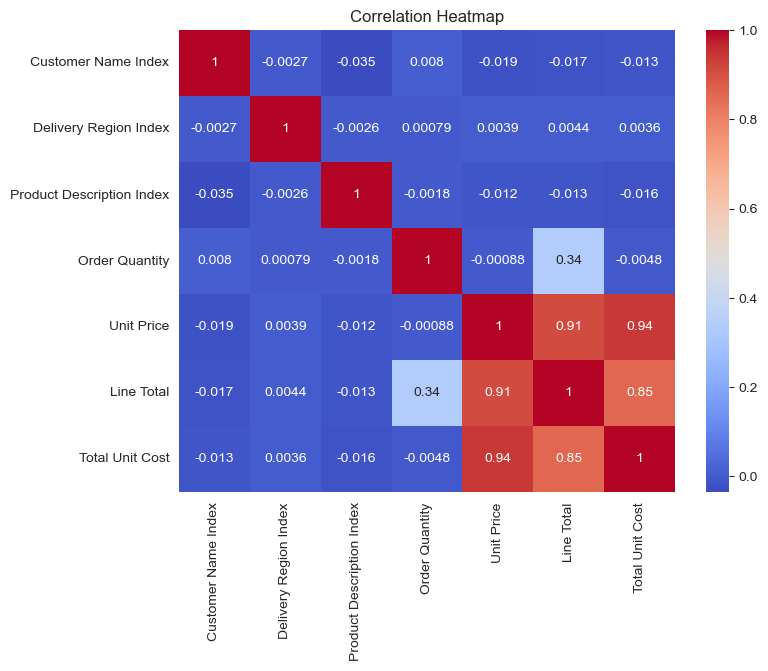

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

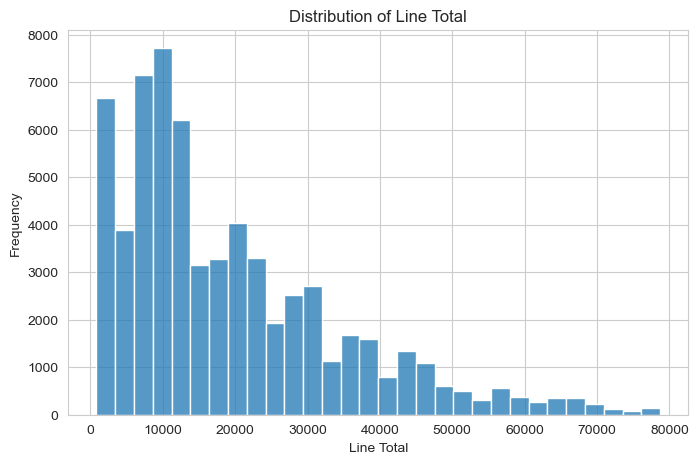

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["Line Total"], bins=30)

plt.title("Distribution of Line Total")

plt.xlabel("Line Total")

plt.ylabel("Frequency")

plt.show()

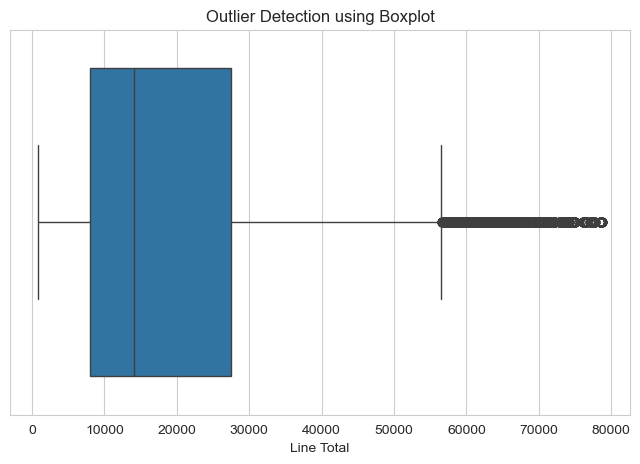

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Line Total"])

plt.title("Outlier Detection using Boxplot")

plt.show()

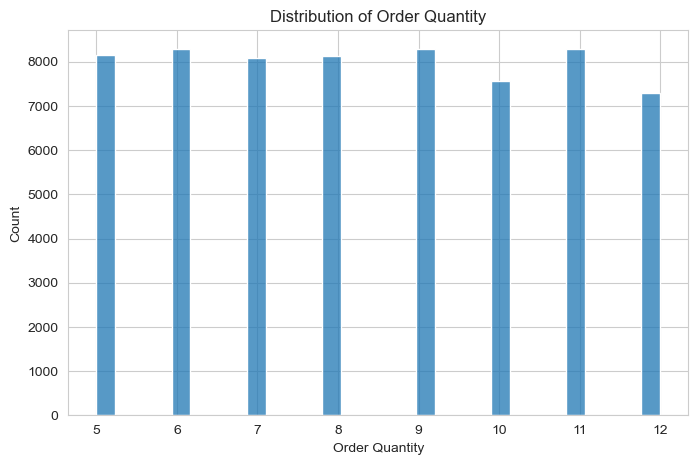

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["Order Quantity"], bins=30)

plt.title("Distribution of Order Quantity")

plt.show()

In [28]:
channel_sales = df.groupby("Channel")["Line Total"].sum()

channel_sales

Channel
Distributor    387139788.6
Export         180631866.0
Wholesale      668197244.4
Name: Line Total, dtype: float64

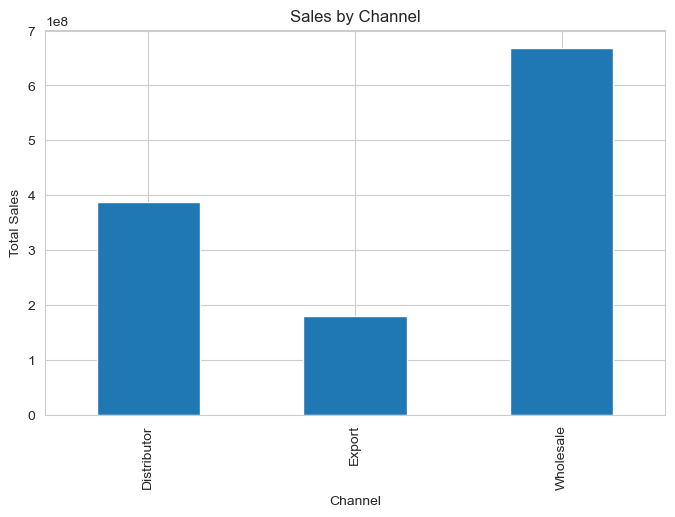

In [29]:
plt.figure(figsize=(8,5))

channel_sales.plot(kind="bar")

plt.title("Sales by Channel")

plt.xlabel("Channel")

plt.ylabel("Total Sales")

plt.show()

In [30]:
currency_sales = df.groupby("Currency Code")["Line Total"].sum()

currency_sales

Currency Code
USD    1.235969e+09
Name: Line Total, dtype: float64

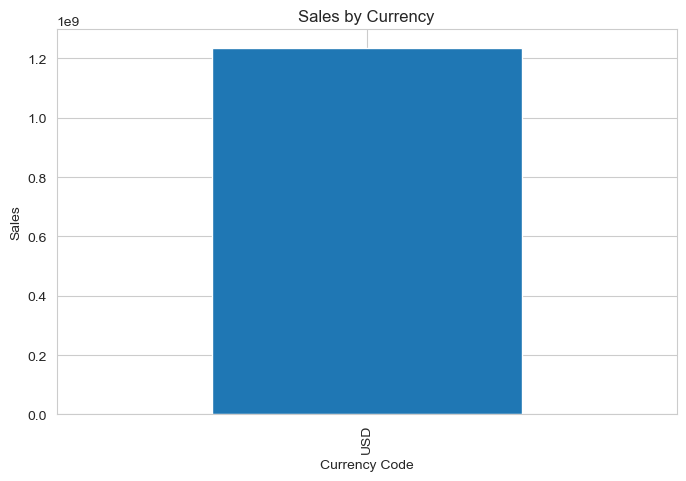

In [31]:
plt.figure(figsize=(8,5))

currency_sales.plot(kind="bar")

plt.title("Sales by Currency")

plt.ylabel("Sales")

plt.show()

In [32]:
warehouse_sales = df.groupby("Warehouse Code")["Line Total"].sum()

warehouse_sales

Warehouse Code
AXW291    585461986.2
FLR025    126984162.0
GUT930    287736123.0
NXH382    235786627.8
Name: Line Total, dtype: float64

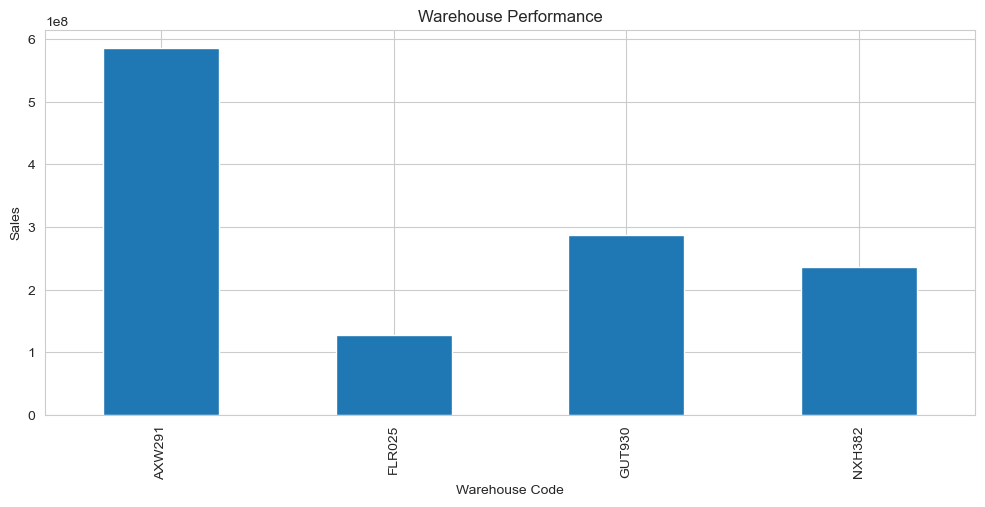

In [33]:
plt.figure(figsize=(12,5))

warehouse_sales.plot(kind="bar")

plt.title("Warehouse Performance")

plt.ylabel("Sales")

plt.show()

In [34]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

In [35]:
df["Month"] = df["OrderDate"].dt.to_period("M")

In [36]:
monthly_sales = df.groupby("Month")["Line Total"].sum()

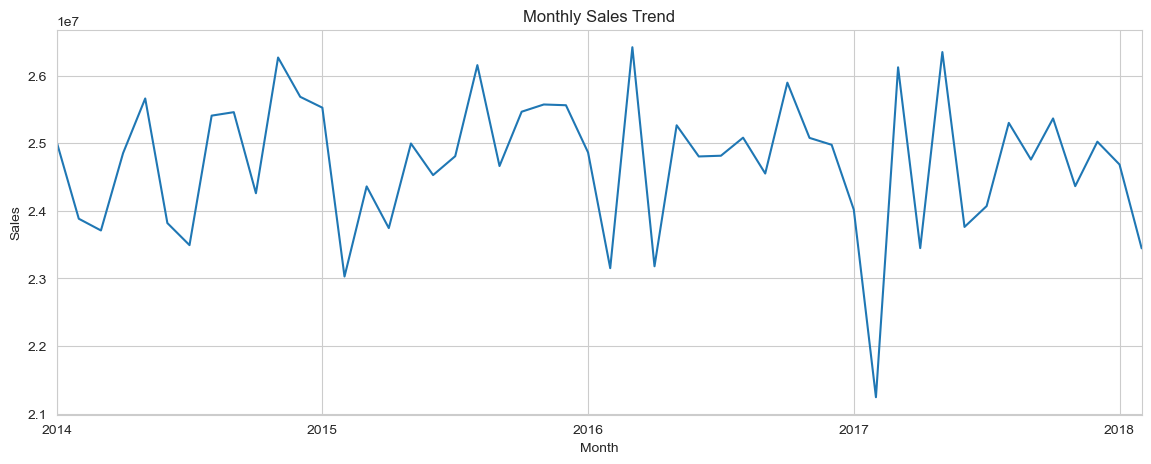

In [37]:
plt.figure(figsize=(14,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

In [38]:
top_products = (
    df.groupby("Product Description Index")["Line Total"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Description Index
26    117291821.4
25    109473966.6
13     78281379.6
14     75390396.6
5      70804380.6
15     67331623.2
2      57401097.6
4      56701537.2
1      55952289.6
3      51764816.4
Name: Line Total, dtype: float64

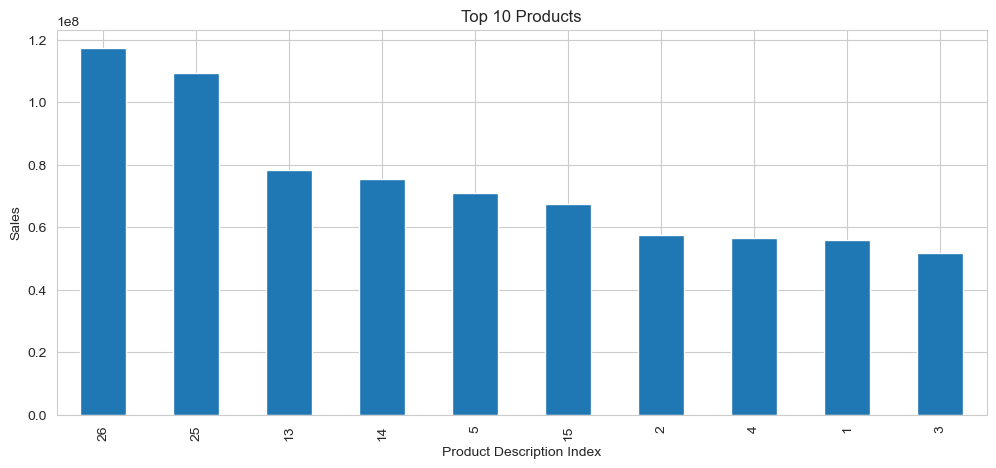

In [39]:
plt.figure(figsize=(12,5))

top_products.plot(kind="bar")

plt.title("Top 10 Products")

plt.ylabel("Sales")

plt.show()

In [40]:
print("Total Sales :", df["Line Total"].sum())

Total Sales : 1235968899.0


In [41]:
print("Average Sales :", df["Line Total"].mean())

Average Sales : 19280.68293710221


In [42]:
print("Highest Sale :", df["Line Total"].max())

Highest Sale : 78711.6


In [43]:
print("Lowest Sale :", df["Line Total"].min())

Lowest Sale : 837.5


In [44]:
print(df["Unit Price"].mean())

2284.380803070011


In [45]:
print(df["Order Quantity"].sum())

541146


In [46]:
print(df["Warehouse Code"].nunique())

4


In [47]:
print(df["Product Description Index"].nunique())

30


In [48]:
Q1 = df["Line Total"].quantile(0.25)

Q3 = df["Line Total"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR

upper = Q3+1.5*IQR

outliers = df[(df["Line Total"]<lower) | (df["Line Total"]>upper)]

print("Number of Outliers:",len(outliers))

outliers.head()

Number of Outliers: 2208


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Month
5,SO - 0010394,2014-01-01,138,Export,USD,NXH382,626,23,11,5219.3,57412.3,4332.019,2014-01
31,SO - 0002921,2014-01-01,66,Wholesale,USD,AXW291,676,26,10,5875.9,58759.0,4289.407,2014-01
117,SO - 0008833,2014-01-03,126,Wholesale,USD,NXH382,292,4,10,6371.7,63717.0,2803.548,2014-01
126,SO - 0004460,2014-01-03,108,Wholesale,USD,GUT930,681,20,12,5688.3,68259.6,4152.459,2014-01
142,SO - 0004592,2014-01-04,21,Wholesale,USD,AXW291,48,12,12,5406.9,64882.8,3676.692,2014-01


In [49]:
print("="*50)
print("EDA COMPLETED SUCCESSFULLY")
print("="*50)

print("Dataset Shape :",df.shape)

print("Total Sales :",df["Line Total"].sum())

print("Average Sales :",df["Line Total"].mean())

EDA COMPLETED SUCCESSFULLY
Dataset Shape : (64104, 13)
Total Sales : 1235968899.0
Average Sales : 19280.68293710221
